In [148]:
import pandas as pd
import numpy as np

# Load dataset from our GitHub repository
url = "https://raw.githubusercontent.com/Aakriti-chadha/digital-twin-smart-agriculture/main/data/raw/Crop_recommendation.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2200, 8)


In [149]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [151]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [152]:
print("Number of crop classes:", df["label"].nunique())
print("\nCrop classes:")
print(df["label"].unique())

Number of crop classes: 22

Crop classes:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [153]:
df["label"].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [154]:
X = df.drop("label", axis=1)
y = df["label"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Input features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target variable:
label


In [155]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1760
Testing samples: 440


In [156]:
# Separate features and target

X = df.drop("label", axis=1)
y = df["label"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nDataset shape:")
print(X.shape)

Features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target:
label

Dataset shape:
(2200, 7)


In [157]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1760
Testing samples: 440


In [158]:
!pip install xgboost -q
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [159]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train_encoded)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [160]:
y_pred_encoded = model.predict(X_test)

print("First 10 predicted values:")
print(y_pred_encoded[:10])

First 10 predicted values:
[16  1  6 11 16  3 20  2  1 16]


In [161]:
y_pred = label_encoder.inverse_transform(y_pred_encoded)

print("First 10 predicted crops:")
print(y_pred[:10])

First 10 predicted crops:
['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [162]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:", accuracy)
print("XGBoost Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 0.9863636363636363
XGBoost Accuracy (%): 98.63636363636363

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.85      0.92        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.91      1.00      0.95        20
   muskmelon       1.00      1.00 

In [163]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_encoded)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [164]:
rf_pred_encoded = rf_model.predict(X_test)

rf_pred = label_encoder.inverse_transform(rf_pred_encoded)

print("First 10 Random Forest predictions:")
print(rf_pred[:10])

First 10 Random Forest predictions:
['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [165]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9954545454545455
Random Forest Accuracy (%): 99.54545454545455

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.0

In [166]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison

,Model,Accuracy,Accuracy (%)
0,XGBoost,0.986364,98.636364
1,Random Forest,0.995455,99.545455


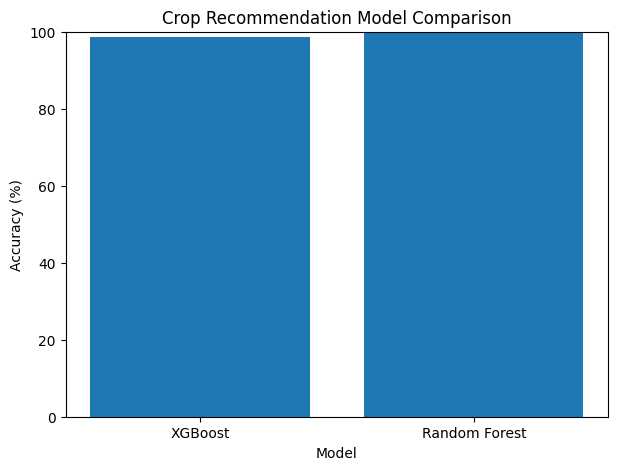

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Crop Recommendation Model Comparison")
plt.ylim(0, 100)

plt.show()

In [168]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
6     rainfall    0.193152
1            P    0.183441
2            K    0.170893
4     humidity    0.166262
0            N    0.158329
3  temperature    0.073694
5           ph    0.054229


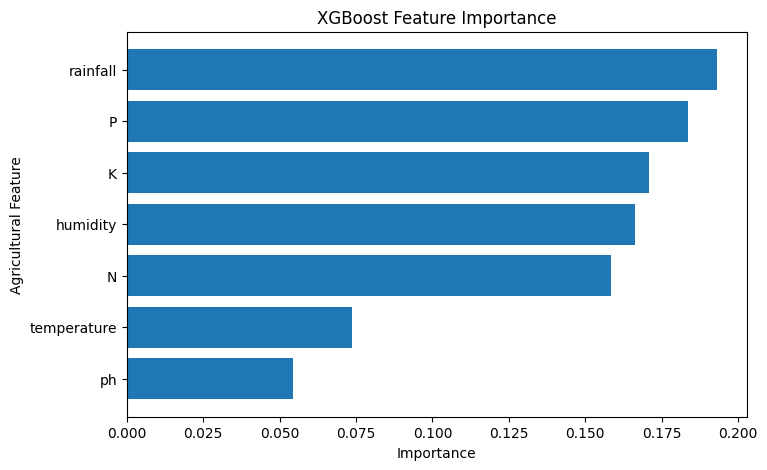

In [169]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Agricultural Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [170]:
# STEP 16.1 - Create a Virtual Farm State

farm_state = {
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 25,
    "humidity": 80,
    "ph": 6.5,
    "rainfall": 200
}

print("DIGITAL TWIN - CURRENT FARM STATE")
print("----------------------------------")

for feature, value in farm_state.items():
    print(f"{feature}: {value}")

DIGITAL TWIN - CURRENT FARM STATE
----------------------------------
N: 90
P: 42
K: 43
temperature: 25
humidity: 80
ph: 6.5
rainfall: 200


In [171]:
# STEP 16.2 - Predict Crop from Digital Twin State

farm_input = pd.DataFrame([farm_state])

# Make sure the feature order is exactly the same as during training
farm_input = farm_input[X.columns]

predicted_crop = model.predict(farm_input)[0]

print("Digital Twin Crop Prediction")
print("----------------------------")
print("Recommended Crop:", predicted_crop)

Digital Twin Crop Prediction
----------------------------
Recommended Crop: 8


In [172]:
# STEP 17 - Extended Digital Twin State

digital_twin = {
    "farm_id": "FARM_001",

    # Environmental conditions
    "temperature": 25,
    "humidity": 80,
    "rainfall": 200,

    # Soil conditions
    "N": 90,
    "P": 42,
    "K": 43,
    "ph": 6.5,

    # Additional twin state
    "soil_moisture": 35,
    "irrigation": 0
}

print("DIGITAL TWIN FARM")
print("=================")

for key, value in digital_twin.items():
    print(f"{key}: {value}")

DIGITAL TWIN FARM
farm_id: FARM_001
temperature: 25
humidity: 80
rainfall: 200
N: 90
P: 42
K: 43
ph: 6.5
soil_moisture: 35
irrigation: 0


In [173]:
# STEP 18 - Digital Twin Prediction Function

def predict_crop(twin_state):

    model_features = [
        "N",
        "P",
        "K",
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ]

    input_data = pd.DataFrame([{
        feature: twin_state[feature]
        for feature in model_features
    }])

    input_data = input_data[X.columns]

    prediction = model.predict(input_data)[0]

    return prediction


current_prediction = predict_crop(digital_twin)

print("Current Crop Recommendation:", current_prediction)

Current Crop Recommendation: 8


In [174]:
# STEP 19 - Create Agricultural Scenarios

scenarios = {
    "Current Conditions": {
        "temperature": digital_twin["temperature"],
        "humidity": digital_twin["humidity"],
        "rainfall": digital_twin["rainfall"]
    },

    "Low Rainfall": {
        "temperature": digital_twin["temperature"],
        "humidity": 65,
        "rainfall": 100
    },

    "High Rainfall": {
        "temperature": digital_twin["temperature"],
        "humidity": 90,
        "rainfall": 300
    },

    "High Temperature": {
        "temperature": 35,
        "humidity": digital_twin["humidity"],
        "rainfall": digital_twin["rainfall"]
    },

    "Cooler Conditions": {
        "temperature": 18,
        "humidity": digital_twin["humidity"],
        "rainfall": digital_twin["rainfall"]
    }
}

print("Agricultural Scenarios")
print("======================")

for scenario, values in scenarios.items():
    print(scenario, ":", values)

Agricultural Scenarios
Current Conditions : {'temperature': 25, 'humidity': 80, 'rainfall': 200}
Low Rainfall : {'temperature': 25, 'humidity': 65, 'rainfall': 100}
High Rainfall : {'temperature': 25, 'humidity': 90, 'rainfall': 300}
High Temperature : {'temperature': 35, 'humidity': 80, 'rainfall': 200}
Cooler Conditions : {'temperature': 18, 'humidity': 80, 'rainfall': 200}


In [175]:
# STEP 20 - Predict Crop for Each Scenario

scenario_results = []

for scenario_name, changes in scenarios.items():

    scenario_state = digital_twin.copy()

    # Apply scenario changes
    scenario_state.update(changes)

    # Predict crop
    prediction = predict_crop(scenario_state)

    scenario_results.append({
        "Scenario": scenario_name,
        "Temperature": scenario_state["temperature"],
        "Humidity": scenario_state["humidity"],
        "Rainfall": scenario_state["rainfall"],
        "Predicted Crop": prediction
    })

scenario_results_df = pd.DataFrame(scenario_results)

print(scenario_results_df)

             Scenario  Temperature  Humidity  Rainfall  Predicted Crop
0  Current Conditions           25        80       200               8
1        Low Rainfall           25        65       100              11
2       High Rainfall           25        90       300              20
3    High Temperature           35        80       200               8
4   Cooler Conditions           18        80       200               8


In [176]:
# STEP 21 - Irrigation Simulation

def simulate_irrigation(twin_state, irrigation_minutes):

    new_state = twin_state.copy()

    # Simple simulation assumption:
    # every 10 minutes of irrigation increases soil moisture by 5%
    moisture_increase = (irrigation_minutes / 10) * 5

    new_state["soil_moisture"] = min(
        100,
        new_state["soil_moisture"] + moisture_increase
    )

    new_state["irrigation"] = irrigation_minutes

    return new_state


irrigation_10 = simulate_irrigation(digital_twin, 10)
irrigation_20 = simulate_irrigation(digital_twin, 20)
irrigation_30 = simulate_irrigation(digital_twin, 30)

print("Irrigation Scenarios")
print("====================")

print("10 minutes:", irrigation_10["soil_moisture"], "% soil moisture")
print("20 minutes:", irrigation_20["soil_moisture"], "% soil moisture")
print("30 minutes:", irrigation_30["soil_moisture"], "% soil moisture")

Irrigation Scenarios
10 minutes: 40.0 % soil moisture
20 minutes: 45.0 % soil moisture
30 minutes: 50.0 % soil moisture


In [177]:
# STEP 22 - Irrigation Scenario Analysis

irrigation_levels = [0, 10, 20, 30, 40]

irrigation_results = []

for minutes in irrigation_levels:

    scenario_state = simulate_irrigation(
        digital_twin,
        minutes
    )

    prediction = predict_crop(scenario_state)

    irrigation_results.append({
        "Irrigation (min)": minutes,
        "Soil Moisture (%)": scenario_state["soil_moisture"],
        "Predicted Crop": prediction
    })

irrigation_results_df = pd.DataFrame(irrigation_results)

print(irrigation_results_df)

   Irrigation (min)  Soil Moisture (%)  Predicted Crop
0                 0               35.0               8
1                10               40.0               8
2                20               45.0               8
3                30               50.0               8
4                40               55.0               8


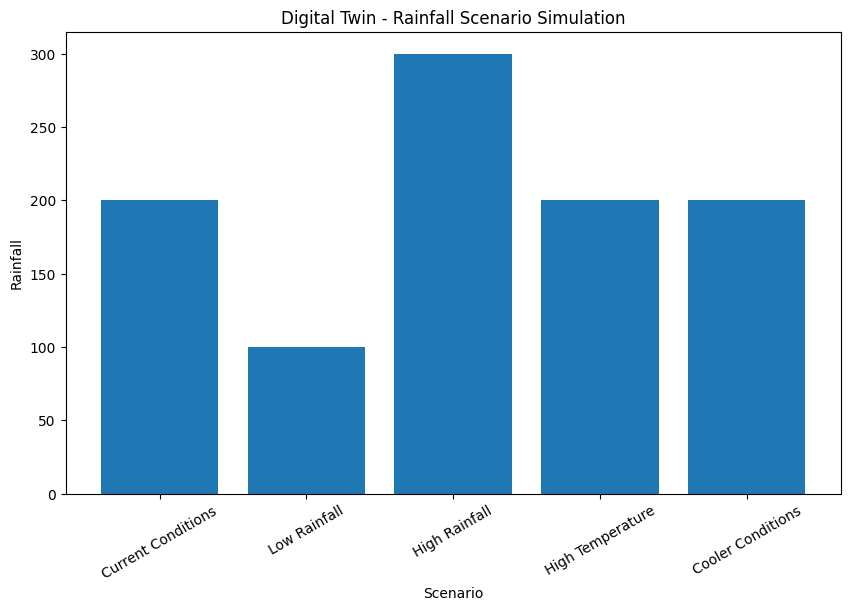

In [178]:
# STEP 23 - Scenario Visualization

plt.figure(figsize=(10, 6))

plt.bar(
    scenario_results_df["Scenario"],
    scenario_results_df["Rainfall"]
)

plt.xlabel("Scenario")
plt.ylabel("Rainfall")
plt.title("Digital Twin - Rainfall Scenario Simulation")

plt.xticks(rotation=30)

plt.show()

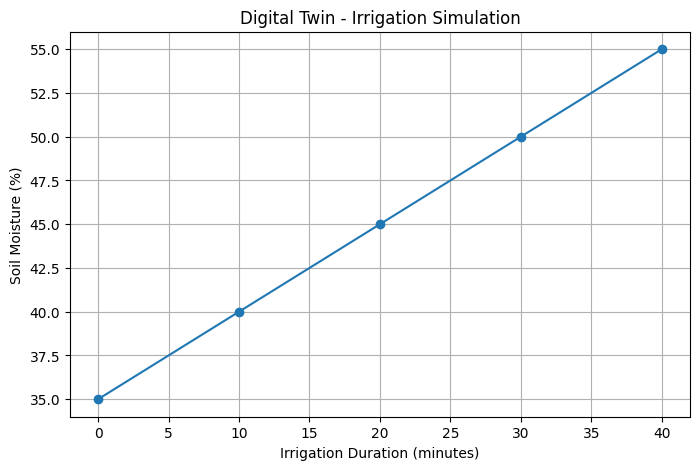

In [179]:
# STEP 24 - Soil Moisture vs Irrigation

plt.figure(figsize=(8, 5))

plt.plot(
    irrigation_results_df["Irrigation (min)"],
    irrigation_results_df["Soil Moisture (%)"],
    marker="o"
)

plt.xlabel("Irrigation Duration (minutes)")
plt.ylabel("Soil Moisture (%)")
plt.title("Digital Twin - Irrigation Simulation")

plt.grid(True)

plt.show()

In [180]:
# step-25-Irrigration Decision Support

def irrigation_recommendation(soil_moisture):

    if soil_moisture < 30:
        return "High irrigation required"

    elif soil_moisture < 50:
        return "Moderate irrigation recommended"

    elif soil_moisture < 70:
        return "Soil moisture is adequate"

    else:
        return "Avoid irrigation"


for minutes in irrigation_levels:

    scenario_state = simulate_irrigation(
        digital_twin,
        minutes
    )

    recommendation = irrigation_recommendation(
        scenario_state["soil_moisture"]
    )

    print(
        minutes,
        "minutes ->",
        scenario_state["soil_moisture"],
        "% ->",
        recommendation
    )

0 minutes -> 35.0 % -> Moderate irrigation recommended
10 minutes -> 40.0 % -> Moderate irrigation recommended
20 minutes -> 45.0 % -> Moderate irrigation recommended
30 minutes -> 50.0 % -> Soil moisture is adequate
40 minutes -> 55.0 % -> Soil moisture is adequate


In [181]:
# STEP 26 - Digital Twin Summary

print("=" * 50)
print("        DIGITAL TWIN - FARM SUMMARY")
print("=" * 50)

print("Farm ID:", digital_twin["farm_id"])

print("\nEnvironmental Conditions")
print("-------------------------")
print("Temperature:", digital_twin["temperature"])
print("Humidity:", digital_twin["humidity"])
print("Rainfall:", digital_twin["rainfall"])

print("\nSoil Conditions")
print("----------------")
print("Nitrogen (N):", digital_twin["N"])
print("Phosphorus (P):", digital_twin["P"])
print("Potassium (K):", digital_twin["K"])
print("pH:", digital_twin["ph"])
print("Soil Moisture:", digital_twin["soil_moisture"])

print("\nML Prediction")
print("----------------")
print("Recommended Crop:", current_prediction)

print("\nDecision Support")
print("----------------")
print(
    irrigation_recommendation(
        digital_twin["soil_moisture"]
    )
)

print("=" * 50)

        DIGITAL TWIN - FARM SUMMARY
Farm ID: FARM_001

Environmental Conditions
-------------------------
Temperature: 25
Humidity: 80
Rainfall: 200

Soil Conditions
----------------
Nitrogen (N): 90
Phosphorus (P): 42
Potassium (K): 43
pH: 6.5
Soil Moisture: 35

ML Prediction
----------------
Recommended Crop: 8

Decision Support
----------------
Moderate irrigation recommended


In [182]:
# STEP 27 - Save Results

scenario_results_df.to_csv(
    "digital_twin_scenarios.csv",
    index=False
)

irrigation_results_df.to_csv(
    "irrigation_simulation.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [183]:
# STEP 28 - Save XGBoost Model

import joblib

joblib.dump(
    model,
    "xgboost_crop_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [4]:
import os

print("Current files:")
for file in os.listdir():
    print(file)

Current files:
.config
sample_data


In [5]:
# STEP 28R - Restore XGBoost Model After Runtime Reset

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("Crop_recommendation.csv")

# Features and target
X = df.drop("label", axis=1)
y = df["label"]

# Encode crop labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Same train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Train XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

# Save model
joblib.dump(model, "xgboost_crop_model.pkl")

# Save label encoder too
joblib.dump(label_encoder, "crop_label_encoder.pkl")

print("XGBoost model restored and saved successfully!")

XGBoost model restored and saved successfully!


In [6]:
# STEP 29 - Reusable Crop Prediction Function

import joblib

model = joblib.load("xgboost_crop_model.pkl")
label_encoder = joblib.load("crop_label_encoder.pkl")

def predict_crop(N, P, K, temperature, humidity, ph, rainfall):

    input_data = [[
        N,
        P,
        K,
        temperature,
        humidity,
        ph,
        rainfall
    ]]

    prediction = model.predict(input_data)

    crop_name = label_encoder.inverse_transform(
        prediction.astype(int)
    )[0]

    return crop_name


crop = predict_crop(
    N=90,
    P=42,
    K=43,
    temperature=20.87,
    humidity=82.00,
    ph=6.50,
    rainfall=202.93
)

print("Recommended Crop:", crop)

Recommended Crop: rice


In [7]:
# STEP 30 - Connect Digital Twin State to Crop Prediction

digital_twin = {
    "farm_id": "Farm_001",
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 25.0,
    "humidity": 80.0,
    "ph": 6.5,
    "rainfall": 200.0,
    "soil_moisture": 35.0
}

recommended_crop = predict_crop(
    digital_twin["N"],
    digital_twin["P"],
    digital_twin["K"],
    digital_twin["temperature"],
    digital_twin["humidity"],
    digital_twin["ph"],
    digital_twin["rainfall"]
)

print("Digital Twin Farm:", digital_twin["farm_id"])
print("Recommended Crop:", recommended_crop)

Digital Twin Farm: Farm_001
Recommended Crop: jute


In [8]:
# STEP 31 - Create Prediction Module

prediction_code = '''
import joblib

model = joblib.load("xgboost_crop_model.pkl")
label_encoder = joblib.load("crop_label_encoder.pkl")

def predict_crop(N, P, K, temperature, humidity, ph, rainfall):

    input_data = [[
        N,
        P,
        K,
        temperature,
        humidity,
        ph,
        rainfall
    ]]

    prediction = model.predict(input_data)

    return label_encoder.inverse_transform(
        prediction.astype(int)
    )[0]
'''

with open("predict_crop.py", "w") as f:
    f.write(prediction_code)

print("predict_crop.py created successfully!")

predict_crop.py created successfully!


In [9]:
# STEP 32 - Create requirements.txt

requirements = """pandas
numpy
matplotlib
scikit-learn
xgboost
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [10]:
# STEP 33 - Digital Twin Irrigation Scenario Analysis

current_moisture = digital_twin["soil_moisture"]

irrigation_minutes = [0, 10, 20, 30]

scenario_results = []

for minutes in irrigation_minutes:

    predicted_moisture = min(
        current_moisture + minutes * 1.0,
        100
    )

    scenario_results.append({
        "Farm_ID": digital_twin["farm_id"],
        "Irrigation_Minutes": minutes,
        "Initial_Soil_Moisture": current_moisture,
        "Predicted_Soil_Moisture": predicted_moisture
    })

scenario_df = pd.DataFrame(scenario_results)

print(scenario_df)

    Farm_ID  Irrigation_Minutes  Initial_Soil_Moisture  \
0  Farm_001                   0                   35.0   
1  Farm_001                  10                   35.0   
2  Farm_001                  20                   35.0   
3  Farm_001                  30                   35.0   

   Predicted_Soil_Moisture  
0                     35.0  
1                     45.0  
2                     55.0  
3                     65.0  


In [11]:
# STEP 34 - Save Scenario Results

scenario_df.to_csv(
    "digital_twin_irrigation_scenarios.csv",
    index=False
)

print("Scenario results saved successfully!")

Scenario results saved successfully!


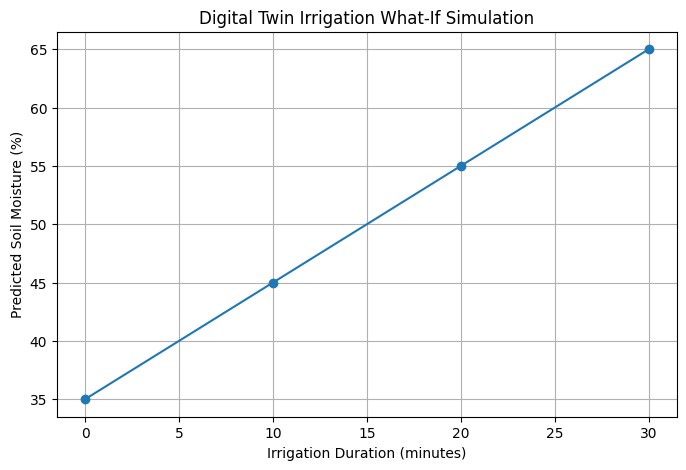

In [12]:
# STEP 35 - Digital Twin Irrigation Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    scenario_df["Irrigation_Minutes"],
    scenario_df["Predicted_Soil_Moisture"],
    marker="o"
)

plt.xlabel("Irrigation Duration (minutes)")
plt.ylabel("Predicted Soil Moisture (%)")
plt.title("Digital Twin Irrigation What-If Simulation")

plt.grid(True)
plt.show()

In [13]:
# STEP 36 - Digital Twin Summary

print("=" * 45)
print("       DIGITAL TWIN FARM SUMMARY")
print("=" * 45)

print(f"Farm ID              : {digital_twin['farm_id']}")
print(f"N                    : {digital_twin['N']}")
print(f"P                    : {digital_twin['P']}")
print(f"K                    : {digital_twin['K']}")
print(f"Temperature          : {digital_twin['temperature']} °C")
print(f"Humidity             : {digital_twin['humidity']} %")
print(f"Soil pH              : {digital_twin['ph']}")
print(f"Rainfall             : {digital_twin['rainfall']} mm")
print(f"Soil Moisture        : {digital_twin['soil_moisture']} %")
print(f"Recommended Crop     : {recommended_crop}")

print("=" * 45)
print("Irrigation Scenarios")
print("=" * 45)

print(scenario_df)

       DIGITAL TWIN FARM SUMMARY
Farm ID              : Farm_001
N                    : 90
P                    : 42
K                    : 43
Temperature          : 25.0 °C
Humidity             : 80.0 %
Soil pH              : 6.5
Rainfall             : 200.0 mm
Soil Moisture        : 35.0 %
Recommended Crop     : jute
Irrigation Scenarios
    Farm_ID  Irrigation_Minutes  Initial_Soil_Moisture  \
0  Farm_001                   0                   35.0   
1  Farm_001                  10                   35.0   
2  Farm_001                  20                   35.0   
3  Farm_001                  30                   35.0   

   Predicted_Soil_Moisture  
0                     35.0  
1                     45.0  
2                     55.0  
3                     65.0  


In [14]:
# STEP 37 - Check Project Files

import os

important_files = [
    "Crop_recommendation.csv",
    "xgboost_crop_model.pkl",
    "crop_label_encoder.pkl",
    "feature_importance.csv",
    "digital_twin_irrigation_scenarios.csv",
    "predict_crop.py",
    "requirements.txt"
]

print("PROJECT FILE CHECK")
print("==================")

for file in important_files:

    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

PROJECT FILE CHECK
✅ Crop_recommendation.csv
✅ xgboost_crop_model.pkl
✅ crop_label_encoder.pkl
❌ feature_importance.csv
✅ digital_twin_irrigation_scenarios.csv
✅ predict_crop.py
✅ requirements.txt


In [17]:
# STEP 37 - Check Project Files

import os

important_files = [
    "Crop_recommendation.csv",
    "xgboost_crop_model.pkl",
    "crop_label_encoder.pkl",
    "feature_importance.csv",
    "digital_twin_irrigation_scenarios.csv",
    "predict_crop.py",
    "requirements.txt"
]

print("PROJECT FILE CHECK")
print("==================")

for file in important_files:

    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

PROJECT FILE CHECK
✅ Crop_recommendation.csv
✅ xgboost_crop_model.pkl
✅ crop_label_encoder.pkl
✅ feature_importance.csv
✅ digital_twin_irrigation_scenarios.csv
✅ predict_crop.py
✅ requirements.txt


In [15]:
# Recreate feature importance CSV

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("feature_importance.csv created successfully!")
print(feature_importance)

feature_importance.csv created successfully!
       Feature  Importance
6     rainfall    0.193152
1            P    0.183441
2            K    0.170893
4     humidity    0.166262
0            N    0.158329
3  temperature    0.073694
5           ph    0.054229


In [16]:
import os

print(os.path.exists("feature_importance.csv"))

True


In [18]:
from google.colab import files

files.download("xgboost_crop_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from google.colab import files

files.download("crop_label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from google.colab import files

files.download("predict_crop.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from google.colab import files

files.download("digital_twin_irrigation_scenarios.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# Recreate feature importance result

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("feature_importance.csv created successfully!")
print(feature_importance)

feature_importance.csv created successfully!
       Feature  Importance
6     rainfall    0.193152
1            P    0.183441
2            K    0.170893
4     humidity    0.166262
0            N    0.158329
3  temperature    0.073694
5           ph    0.054229


In [24]:
import os
print(os.path.exists("feature_importance.csv"))

True


In [25]:
from google.colab import files
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>